In [93]:
#%%
import math
import numpy as np
import inspect
import importlib

import scipy.interpolate

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Impact_model                        import *
from IoT_node_models.Analysis                            import *

path_to_save_svg = "Saved_Data"



In [94]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [95]:
RX_module_3V3 = Node_module(name="LoRa radio",
                            v=3.3,
                            i_sleep=6e-3)
RX_state_TX_3V3 = Module_state("TX",i = 52,duration = None)
RX_state_RX_3V3 = Module_state("RX",i = 22,duration = None)
RX_module_3V3.add_state(RX_state_TX_3V3)
RX_module_3V3.add_state(RX_state_RX_3V3)


MCU_module_3V3 = Node_module(name="Apollo3",
                            v      =3.3,
                            i_sleep=0)
MCU_state_active_3V3  = Module_state("Active",i = 0,duration = None)
MCU_module_3V3.add_state(MCU_state_active_3V3)

In [96]:
node_LDO = LDO(name = "Node LDO", v_out = 3.3, i_q = 1e-3, v_in = 3.3, module_list = module_List_3V3)
node_Batt= Battery(name = "Node Batt.", v = 3.3, capacity_mAh = 2800, i = 0, selfdischarge_p_year = 5)

node_lora = LoRa_Node(name= "IoT Node", module_list= module_List_3V3, PMU_composition =[node_LDO], Battery = node_Batt, radio_module = radio_module_3V3)

node= LoRa_Node_profile("Node_profile", node_lora,  RX_state=radio_state_RX_3V3,TX_state=radio_state_TX_3V3,
                    P_TX= PTX_PABOOST_3V3, I_TX=I_PABoost_3V3 ) 
              
this_task_tx0 = node.create_task_tx(name="TX-0", Ptx = 17,SF=7 ,Coding=1,Header=True,DE = 1,BW = 125e3, Payload = 50, TX_rate=24*1)
this_task_rx0 = node.create_task_rx(name="RX-0", RX_rate=2, RX_duration=0.250 )


node.add_task(task_TPHG_3V3,24*12)
node.add_task(task_TPH_3V3 ,0)

In [97]:
def PL_model(d):
    return path_loss_PLd0(d=d, PLd0=94.40,d0=1, n=2.03)

this_task_tx0.set_Path_loss_model(PL_model)


this_task_tx0.set_distance( d= 1500)

-------------------------------------------------
            Tasks summary                        
-------------------------------------------------
Task name            : Sleep          TX-0           RX-0           TPHG meas.     TPH meas.      
Times/day    [1/d]   : 1              24             2              288            0              
Tot. durat.  [s]     : 85715.4544     55.2468        0.5000         628.7988       0.0000         
Tot. en./d   [mJ]    : 983.6039       21705.0765     18.6167        23484.1887     0.0000         
Node en./d   [mJ]    : 46191.4858      
Average pow. [mW]    : 0.5346          
-------------------------------------------------
-----------------------------------------------------------------
                        Module summary                           
-----------------------------------------------------------------
Module       State        Active [s]   Energy [mJ]  Av. Cur.[uA]  
Apollo3                   615.3607     1934.0443    6.78326

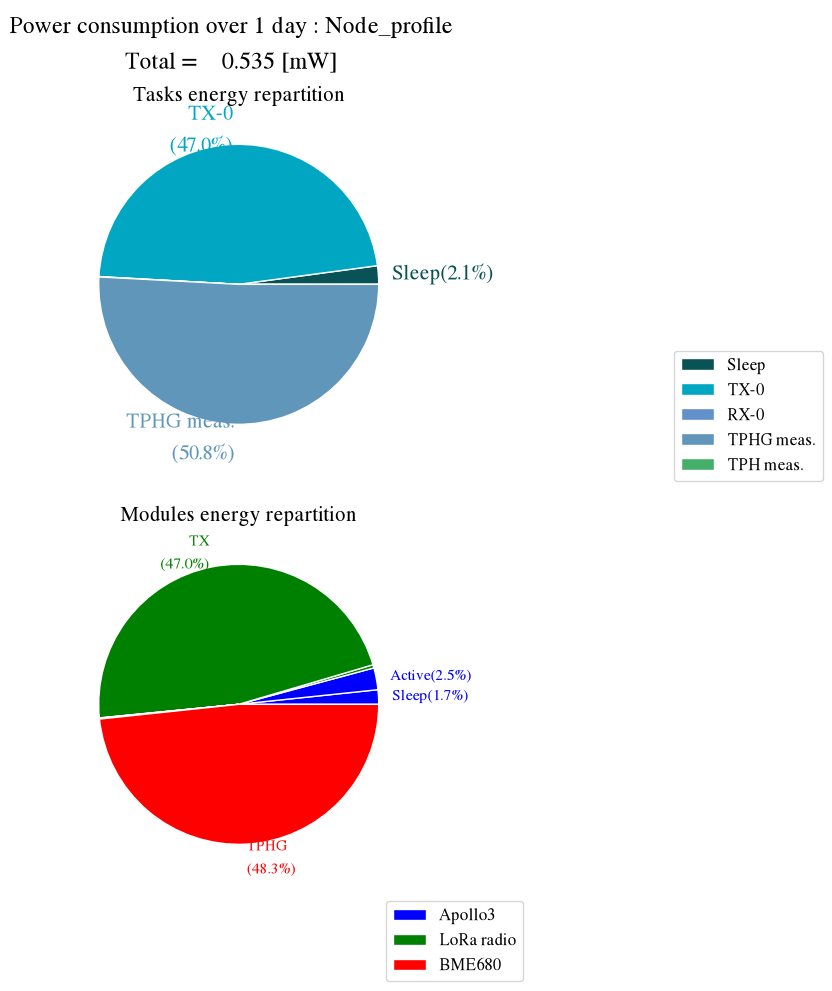

In [98]:

node.compute()
node.print_Tasks()
node.print_Modules()
node.plot_Power()

In [ ]:
show = 1

AA_series = 3
AA_footprint = 0.165
AA_cost      = 0.25 
Batt_footprint = AA_series*AA_footprint
Batt_cost      = AA_series*AA_cost

placementNnodes   = 100
decomNnodes       = 100
replacementNnodes = 10

transport_f =   transport_footprint(km_p_node = 1, 
                                    km_fixed  = 40
                                    type ="Unit", 
                                    n_node = 1,
                                    footprint_p_km = 0.350)

transport_c =   transport_cost( worker = 1, 
                               salary_p_hour = 20, 
                               work_hour_p_node =0.3, km_p_h = 50,
                               km_fixed = 10, 
                               type ="Unit", 
                               n_node = 1,cost_p_km = 0.2)
    

node_footprint = Node_BoM(  casing            =[0.709,    0.3932, 1.3259], #709
                            connectivtiy      =[0.517,    0.2262, 0.5817],
                            eol               =[0.0812,   0.0388, 0.1201],
                            memory            =[0,        0,      0     ],
                            others            =[0.0938,   0.0546, 0.1394],
                            pcb               =[1.17,     0.9403, 1.5696], #1.17
                            power_supply      =[0.132,    0.0446, 0.1751],
                            processing        =[0.366,    0.366,  0.4537],
                            sensing           =[0.0539,   0.0539, 0.5561],
                            ui                =[0.0306,   0.0017, 0.1155],
                            battery           =[Batt_footprint  ,Batt_footprint,Batt_footprint],)


node_Cost   = Node_BoM(     casing            =[10    ,    0 , 0], #ABS , IP rated
                            connectivtiy      =[5.3   ,    0 , 0], #SX1276 : 5.3
                            eol               =[0     ,    0 , 0],
                            memory            =[0     ,    0 , 0],
                            others            =[1.42  ,    0 , 0], #MLCC : 0.05*15 + XTAL32MHz: 0.5 + R: 0.002*15 + D : 0.07*2  
                            pcb               =[1.17  ,    0 , 0], #PCB 60cm2 : 1.75 
                            power_supply      =[0.228 ,    0 , 0], #XC6206 : 0.228 + Diode and Transistor?
                            processing        =[3.65  ,    0 , 0], #Apollo3: 3.65
                            sensing           =[6.94  ,    0 , 0], #BME680 : 6.94
                            ui                =[0.54  ,    0 , 0], #Push button : 0.17*2 + LED SMD : 0.2*1
                            transport         =[transport_c,0 , 0],
                            battery           =[Batt_cost  ,0 , 0],
                            placement         =[transport_c,0 , 0],
                            replacement       =[transport_c,0 , 0],
                            decom             =[transport_c,0 , 0],
                            placementNnodes   = 100,
                            decomNnodes       = 100,
                            replacementNnodes = 10)


3.6485000000000003


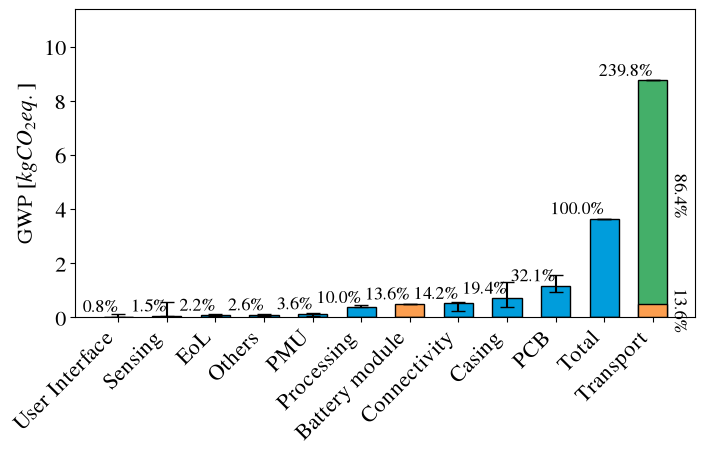

In [100]:
node_footprint.plot_footprint(filename = None ,figsize =(8,4),separatePlot=False)

In [101]:
[res1,res2,lifetime,residue] =deployment_battery_replacement(
                                    Replacement_type = "Complete",
                                    Footprint=node_footprint,
                                    Node=node,
                                    Nyears= 20)
print([res1,res2,lifetime,residue])

[7.876600000000001, np.float64(7.3804069586404655), np.float64(1.7857793679015153), np.float64(0.5346236781463464)]


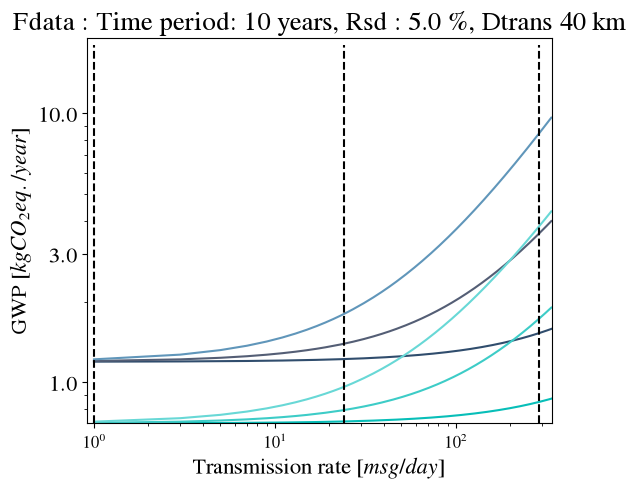

In [105]:

lora_deployment_sweep_fdata(Replacement_strategy = "Battery", 
                       Footprint=node_footprint,
                       Node=node,
                       Nyears=10,
                       dtrans=40,
                       nAA = [1,3]  , 
                       param = [200,700,1200]   , 
                       paramType ="dnode",
                       fmax=24*12+50, 
                       f_step=2         ,
                       Task_tx = this_task_tx0,
                       transport_model=F_trans, 
                       filename = None            ,figsize =(6,5) )

In [87]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(0.1, 5.0)

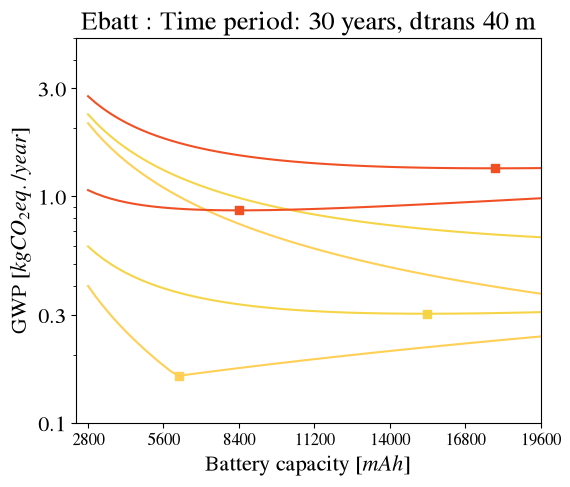

In [88]:

n_years = 30                       
km_trans = 40

node.change_task_rate(task_TPHG_3V3,24*12)
node.change_task_rate(this_task_tx0,24)
this_task_tx0.set_distance(d= 700)

fig , ax = deployment_sweep_ebatt(Replacement_strategy = "Complete", 
                       Footprint=node_footprint,
                       Node=node,
                       Nyears=n_years,
                       dtrans=km_trans,
                       param = [0,3,10] , 
                       paramType ="rsd",
                       nAAmin = 1, 
                       nAAmax=7, 
                       nAA_step=0.1 ,
                       transport_model=F_trans, 
                       filename = None      ,figsize =(6,5) )


node.change_task_rate(task_TPHG_3V3,0)
node.change_task_rate(task_TPH_3V3 ,24*12)

fig , ax = deployment_sweep_ebatt(Replacement_strategy = "Complete", 
                       Footprint=node_footprint,
                       Node=node,
                       Nyears=n_years,
                       dtrans=km_trans,
                       param = [0,3,10] , 
                       paramType ="rsd",
                       nAAmin = 1, 
                       nAAmax=7, 
                       nAA_step=0.1 ,
                       transport_model=F_trans, 
                       filename = None      ,figsize =(6,5) , figAppend=[fig,ax])

ax.set_ylim(ymin = 0.1)
ax.set_ylim(ymax = 5)

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Ebatt : Time period: 30 years, dtrans 40 m'}, xlabel='Battery capacity [$mAh$]', ylabel='GWP [$kgCO_2eq./year$]'>)

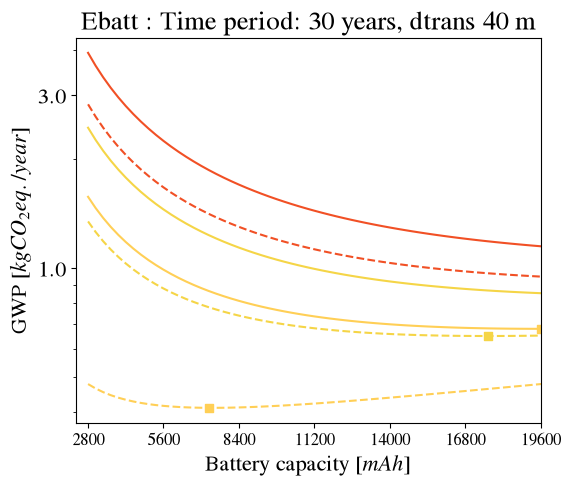

In [92]:

n_years = 30                       
km_trans = 40

node.change_task_rate(task_TPHG_3V3,24*12)
this_task_tx0.set_distance(d= 700)

deployment_sweep_ebatt(Replacement_strategy = "Both", 
                       Footprint=node_footprint,
                       Node=node,
                       Nyears=n_years,
                       dtrans=km_trans,
                       param = [5,40,100] , 
                       paramType ="dtrans",
                       nAAmin = 1, 
                       nAAmax=7, 
                       nAA_step=0.1 ,
                       transport_model=F_trans, 
                       filename = None      ,figsize =(6,5) )
    